# Set-Up

In [1]:
# Imports for Generating & Viewing Data #

import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed

In [2]:
# Constants #

GAUSSIAN_X = 48
GAUSSIAN_Y = 48

MIN_OFFSET_X = -4
MAX_OFFSET_X = 4

MIN_OFFSET_Y = -4
MAX_OFFSET_Y = 4

MIN_STD_X = 5
MAX_STD_X = 11

MIN_STD_Y = 5
MAX_STD_Y = 11

MIN_THETA = 0
MAX_THETA = np.pi

MIN_INTENSITY = 0.2
MAX_INTENSITY = 0.8

# params: [center_x, center_y, std_x, std_y, sin2theta, cos2theta, intensity]
scaling_arr = np.array([48.0, 48.0, 24.0, 24.0, 1.0, 1.0, 1.0], dtype=np.float32)

SEED = 0
rng = np.random.default_rng(SEED)

In [6]:
# Utility Functions for Generating Data #

# TODO: look into parallelizing
def gen_data(num_images: int) -> tuple:

    img_arr = np.empty((num_images, GAUSSIAN_Y, GAUSSIAN_X, 1), dtype=np.float32)
    label_arr = np.empty((num_images, 7), dtype=np.float32)

    for i in tqdm(range(num_images)):
        img, label = img_gen()
        img_arr[i] = img.astype(np.float32) / 256.0             # Normalize values to [0, 1)
        label_arr[i] = label.astype(np.float32) / scaling_arr   # Normalize values using scaling array

    print(f"[Images Shape]: {img_arr.shape}")
    print(f"[Labels Shape]: {label_arr.shape}")

    return (img_arr, label_arr)

def img_gen() -> tuple:

    center_x = GAUSSIAN_X / 2 + rng.uniform(MIN_OFFSET_X, MAX_OFFSET_X)
    center_y = GAUSSIAN_Y / 2 + rng.uniform(MIN_OFFSET_Y, MAX_OFFSET_Y)

    std_x = rng.uniform(MIN_STD_X, MAX_STD_X)
    std_y = rng.uniform(MIN_STD_Y, MAX_STD_Y)
    theta = rng.uniform(MIN_THETA, MAX_THETA)

    intensity = MIN_INTENSITY + rng.random() * (MAX_INTENSITY - MIN_INTENSITY)

    shape_params = np.array([center_x, center_y, std_x, std_y, theta])
    gaussian = np.array(gaussian_gen(*shape_params))
    gaussian = gaussian * intensity * 255
    gaussian = gaussian.astype(np.uint8)

    # params: [cx, cy, sx, sy, sin(2*theta), cos(2*theta), intensity]
    params = np.array([center_x, center_y, std_x, std_y, np.sin(2*theta), np.cos(2*theta), intensity])
    
    return (gaussian, params)

X, Y = np.meshgrid(np.arange(GAUSSIAN_X), np.arange(GAUSSIAN_Y))

def gaussian_gen(
    center_x: float, center_y: float, std_x: float, std_y: float, theta: float, X=X, Y=Y
) -> np.ndarray:

    cos_theta_sqrd = np.power(np.cos(theta), 2)
    sin_theta_sqrd = np.power(np.sin(theta), 2)
    sin_cos_theta = np.sin(theta) * np.cos(theta)

    std_x_sqrd = np.power(std_x, 2)
    std_y_sqrd = np.power(std_y, 2)

    a = (cos_theta_sqrd) / (2 * std_x_sqrd) + (sin_theta_sqrd) / (2 * std_y_sqrd)
    b = -1 * (sin_cos_theta) / (2 * std_x_sqrd) + (sin_cos_theta) / (2 * std_y_sqrd)
    c = (sin_theta_sqrd) / (2 * std_x_sqrd) + (cos_theta_sqrd) / (2 * std_y_sqrd)

    gaussian = np.exp(
        -(
            a * (X - center_x) ** 2
            + 2 * b * (X - center_x) * (Y - center_y)
            + c * (Y - center_y) ** 2
        )
    )

    return np.expand_dims(gaussian, -1)

# Train / Load Qkeras Model

In [4]:
# Imports for Training #

import tensorflow as tf
import keras.backend as K
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Flatten, Dense, Concatenate
from tensorflow.keras.activations import relu, sigmoid
from tensorflow.keras.models import Model
from qkeras import QConv2D, QActivation
from qkeras.quantizers import quantized_bits, quantized_relu

2026-05-04 18:03:36.122127: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-04 18:03:36.123245: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-04 18:03:36.137145: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-04 18:03:36.137165: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-04 18:03:36.137177: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

In [15]:
# Create TF Datasets #
# TODO: look into using tf.data.Dataset.from_generator
TRAINING_DATASET_SIZE = 10000
VALIDATION_DATASET_SIZE = 1000
TEST_DATASET_SIZE = 1000
BATCH_SIZE = 50


train_img_arr, train_label_arr = gen_data(TRAINING_DATASET_SIZE)
val_img_arr, val_label_arr = gen_data(VALIDATION_DATASET_SIZE)
test_img_arr, test_label_arr = gen_data(TEST_DATASET_SIZE)

train_dataset = (
    tf.data.Dataset.from_tensor_slices((train_img_arr, train_img_arr))
    .shuffle(TRAINING_DATASET_SIZE, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((val_img_arr, val_img_arr))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

100%|██████████| 10000/10000 [00:00<00:00, 34214.75it/s]


[Images Shape]: (10000, 48, 48, 1)
[Labels Shape]: (10000, 7)


100%|██████████| 1000/1000 [00:00<00:00, 35332.36it/s]


[Images Shape]: (1000, 48, 48, 1)
[Labels Shape]: (1000, 7)


100%|██████████| 1000/1000 [00:00<00:00, 35137.89it/s]


[Images Shape]: (1000, 48, 48, 1)
[Labels Shape]: (1000, 7)


In [16]:
# Qkeras Model Architecture #
# TODO: Quantize Dense Layers?
TOTAL_BITS = 8
INTEGER_BITS = 0


w_quant = quantized_bits(
    TOTAL_BITS, INTEGER_BITS, symmetric=False, keep_negative=True, alpha=1
)
relu_quant = quantized_relu(TOTAL_BITS, INTEGER_BITS)

input_layer = Input(shape=(GAUSSIAN_Y, GAUSSIAN_X, 1), name='InputLayer')

x = QConv2D(filters=4, kernel_size=3, strides=1, padding='valid', name='qconv2d_1',
    kernel_quantizer=w_quant,
    kernel_initializer='lecun_uniform'
)(input_layer)
# x = BatchNormalization(axis=-1, momentum=0.99, epsilon=1e-03, name='bn1')(x)
x = QActivation(relu_quant, name="qact_1")(x)
x = MaxPool2D(pool_size=3, strides=3, name='pool_1')(x)

x = QConv2D(filters=8, kernel_size=3, strides=1, padding='valid', name='qconv2d_2',
    kernel_quantizer=w_quant,
    kernel_initializer='lecun_uniform'
)(x)
# x = BatchNormalization(axis=-1, momentum=0.99, epsilon=1e-03, name='bn2')(x)
x = QActivation(relu_quant, name="qact_2")(x)
x = MaxPool2D(pool_size=2, strides=2, name='pool_2')(x)

x = QConv2D(filters=12, kernel_size=3, strides=1, padding='valid', name='qconv2d_3',
    kernel_quantizer=w_quant,
    kernel_initializer='lecun_uniform'
)(x)
# x = BatchNormalization(axis=-1, momentum=0.99, epsilon=1e-03, name='bn3')(x)
x = QActivation(relu_quant, name="qact_3")(x)
x = MaxPool2D(pool_size=2, strides=2, name='pool_3')(x)

x = Flatten(name='flatten')(x)
x = Dense(units=20, activation='relu', name='fc1')(x)

# Split head to constrain outputs:
x_center    = Dense(units=2, activation='linear',   name='center')(x)
x_std       = Dense(units=2, activation='softplus', name='std')(x)
x_theta     = Dense(units=2, activation='linear',   name='theta')(x)
x_intensity = Dense(units=1, activation='sigmoid',  name='intensity')(x)

x_p1        = Concatenate(axis=-1, name='params_1')([x_center, x_std])
x_p2        = Concatenate(axis=-1, name='params_2')([x_theta, x_intensity])
x_params    = Concatenate(axis=-1, name='params')([x_p1, x_p2])  # 7-dim

gaussian_qk = Model(inputs=input_layer, outputs=x_params, name='gaussian')

In [17]:
# Tensorflow Functions #
BG_WEIGHT = 0.05


def recon_loss(y_true, y_pred):
    W = y_true + BG_WEIGHT
    return tf.reduce_mean(tf.reduce_sum(W * tf.square(y_true - y_pred), axis=[1, 2, 3]))

scaling_tf = tf.constant(scaling_arr, dtype=tf.float32)
X_mesh_tf, Y_mesh_tf = tf.meshgrid(
    tf.range(GAUSSIAN_X, dtype=tf.float32),
    tf.range(GAUSSIAN_Y, dtype=tf.float32),
)
X_mesh_tf = X_mesh_tf[tf.newaxis, :, :, tf.newaxis]
Y_mesh_tf = Y_mesh_tf[tf.newaxis, :, :, tf.newaxis]
def gaussian_gen_tf(params_norm):
    # params_norm ordering: [cx, cy, sx, sy, sin2t, cos2t, intensity]
    params = params_norm * scaling_tf
    cx  = tf.reshape(params[:, 0], (-1, 1, 1, 1))
    cy  = tf.reshape(params[:, 1], (-1, 1, 1, 1))
    sx  = tf.reshape(params[:, 2], (-1, 1, 1, 1))
    sy  = tf.reshape(params[:, 3], (-1, 1, 1, 1))
    s2t = tf.reshape(params[:, 4], (-1, 1, 1, 1))
    c2t = tf.reshape(params[:, 5], (-1, 1, 1, 1))
    ity = tf.reshape(params[:, 6], (-1, 1, 1, 1))

    norm = tf.sqrt(tf.square(s2t) + tf.square(c2t) + 1e-6)
    s2t = s2t / norm
    c2t = c2t / norm

    cos_sqr = 0.5 * (1.0 + c2t)
    sin_sqr = 0.5 * (1.0 - c2t)
    sin_cos = 0.5 * s2t

    std_x_sqrd = tf.square(sx) + 1e-6
    std_y_sqrd = tf.square(sy) + 1e-6

    a = (cos_sqr) / (2.0 * std_x_sqrd) + (sin_sqr) / (2.0 * std_y_sqrd)
    b = -1.0 * (sin_cos) / (2.0 * std_x_sqrd) + (sin_cos) / (2.0 * std_y_sqrd)
    c = (sin_sqr) / (2.0 * std_x_sqrd) + (cos_sqr) / (2.0 * std_y_sqrd)

    dx = X_mesh_tf - cx
    dy = Y_mesh_tf - cy
    return ity * tf.exp(-(a * tf.square(dx) + 2.0 * b * dx * dy + c * tf.square(dy)))

x_reconstruction = tf.keras.layers.Lambda(gaussian_gen_tf, name='reconstruction')(gaussian_qk.output)
training_model = Model(
    inputs=gaussian_qk.input,
    outputs=x_reconstruction,
    name='gaussian_training',
)

In [18]:
# Train or Load #
# TODO: Fix Load
TRAIN_MODEL = True
LOAD_MODEL = False

NUM_EPOCHS = 100
EARLY_STOPPING_PATIENCE = 10
MIN_DELTA = 1e-4


if TRAIN_MODEL and LOAD_MODEL:
    print("Are you sure you want to Train & Load ?")

elif TRAIN_MODEL:
    adam_optimizer = tf.keras.optimizers.Adam(
        learning_rate=1e-3,
        global_clipnorm=1.0,
    )

    training_model.compile(
        optimizer=adam_optimizer,
        loss=recon_loss,
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOPPING_PATIENCE,
        min_delta=MIN_DELTA,
        restore_best_weights=True,
        verbose=1,
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-5,
        verbose=1,
    )

    history = training_model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=NUM_EPOCHS,
        callbacks=[early_stop, reduce_lr],
        verbose=1,
    )

elif LOAD_MODEL:
    pass
    # from qkeras.utils import _add_supported_quantized_objects
    # co = {}
    # _add_supported_quantized_objects(co)
    # co['loss_wbce'] = loss_wbce
    # baby_yolo_qk = tf.keras.models.load_model(f'../Models/{MODEL_NAME}', custom_objects=co)

gaussian_qk.summary()


Epoch 1/100
200/200 [==============================] - 1s 3ms/step - loss: 7.1802 - val_loss: 4.6761 - lr: 0.0010
Epoch 2/100
200/200 [==============================] - 0s 2ms/step - loss: 4.6084 - val_loss: 3.3349 - lr: 0.0010
Epoch 3/100
200/200 [==============================] - 0s 2ms/step - loss: 1.1050 - val_loss: 0.6506 - lr: 0.0010
Epoch 4/100
200/200 [==============================] - 0s 2ms/step - loss: 0.5558 - val_loss: 0.4872 - lr: 0.0010
Epoch 5/100
200/200 [==============================] - 0s 2ms/step - loss: 0.4718 - val_loss: 0.4255 - lr: 0.0010
Epoch 6/100
200/200 [==============================] - 1s 3ms/step - loss: 0.4266 - val_loss: 0.3894 - lr: 0.0010
Epoch 7/100
200/200 [==============================] - 0s 2ms/step - loss: 0.3803 - val_loss: 0.3592 - lr: 0.0010
Epoch 8/100
200/200 [==============================] - 0s 2ms/step - loss: 0.3491 - val_loss: 0.3087 - lr: 0.0010
Epoch 9/100
200/200 [==============================] - 0s 2ms/step - loss: 0.3242 - val_

# Test QKeras Model

In [ ]:
# Utility Functions for Viewing Data #
# TODO: add comparison functions

In [19]:
# Predict on Test Set #

predictions_qk = gaussian_qk.predict(test_img_arr)

print(f"[Test Shape]: {test_label_arr.shape}")
print(f"[Prediction Shape]: {predictions_qk.shape}")

32/32 [==============================] - 0s 950us/step
[Test Shape]: (1000, 7)
[Prediction Shape]: (1000, 7)


In [35]:
# Emperically Compare Performance #
# TODO: consider better metrics

# Mean Squared Error (per column)
mse = np.mean(((test_label_arr * scaling_arr) - (predictions_qk * scaling_arr)) ** 2, axis=0)

# Mean Absolute Error (per column)
mae = np.mean(np.abs((test_label_arr * scaling_arr) - (predictions_qk * scaling_arr)), axis=0)

print("MSE (per column):", mse)
print("MAE (per column):", mae)

MSE (per column): [8.1231639e-02 7.9760149e-02 2.5096343e+00 2.4370503e+00 5.0305820e-01
 4.9641132e-01 1.7498010e-04]
MAE (per column): [0.20232852 0.2058917  1.1042013  1.0752648  0.63699996 0.63348716
 0.00981059]


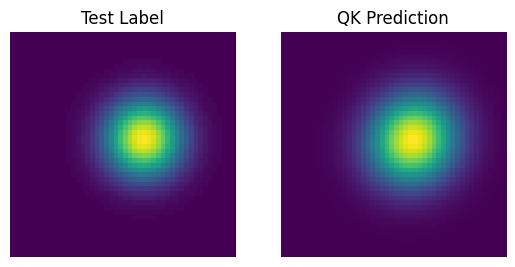

In [34]:
# Visually Compare Predictions #
index = np.random.randint(low=0, high=TEST_DATASET_SIZE)

label_real = test_label_arr[index] * scaling_arr
pred_real = predictions_qk[index] * scaling_arr

# Recover theta from (sin2t, cos2t) via arctan2.
pred_theta  = 0.5 * np.arctan2(pred_real[4],  pred_real[5])

# Reconstruct image using parameters
pred_recon = gaussian_gen(pred_real[0], pred_real[1], pred_real[2], pred_real[3], pred_theta)

fig, axes = plt.subplots(1, 2)
im0 = axes[0].imshow(test_img_arr[index], cmap="viridis", interpolation="none")
axes[0].set_title("Test Label")
axes[0].axis("off")

im1 = axes[1].imshow(pred_recon, cmap="viridis", interpolation="none")
axes[1].set_title("QK Prediction")
axes[1].axis("off")

plt.show()

In [ ]:
# Save Model #
SAVE_MODEL = False

if SAVE_MODEL:
    gaussian_qk.save(f"Models/{MODEL_NAME}")

/home/pujan/Research/Rheed-Gaussian/.venv/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


# Convert to HLS

In [38]:
# Imports for HLS #

import hls4ml
from hls4ml.utils import config_from_keras_model
from pprint import pprint

In [ ]:
# HLS4ML Config #
# TODO: look into pipeline
# TODO: verify config quantization

config = config_from_keras_model(gaussian_qk, granularity="name", backend="Vitis")

# Fifo Depth Optimization (greatly reduces BRAM)
config["Flows"] = ["vitis:fifo_depth_optimization"]
hls4ml.model.optimizer.get_optimizer("vitis:fifo_depth_optimization").configure(
    profiling_fifo_depth=100_000
)

# Strategy
config["Model"]["Strategy"] = "Latency"
# config['Model']['PipelineStyle'] = 'pipeline'

# Reuse Factor
config["Model"]["ReuseFactor"] = 8
for layer_cfg in config["LayerName"].values():
    if "ReuseFactor" in layer_cfg:
        layer_cfg["ReuseFactor"] = 8

# Ensure Proper Quantization
# for layer in config["LayerName"]:
#     if layer.startswith("conv2d_"):  # QConv2D
#         precision = config["LayerName"][layer].get("Precision", {})
#         for key in precision:
#             if precision[key] == "auto":
#                 precision[key] = "fixed<8,0>"
#     if layer.startswith("qact_"):  # QActivation
#         config["LayerName"][layer]["Precision"]["result"] = "fixed<8,0>"

pprint(config)

{'LayerName': {'InputLayer': {'Precision': {'result': 'auto'}, 'Trace': False},
               'center': {'Precision': {'accum': 'auto',
                                        'bias': 'auto',
                                        'result': 'auto',
                                        'weight': 'auto'},
                          'ReuseFactor': 8,
                          'Trace': False},
               'center_linear': {'Precision': {'result': 'auto',
                                               'table': 'fixed<18,8,TRN,WRAP,0>'},
                                 'ReuseFactor': 8,
                                 'TableSize': 1024,
                                 'Trace': False},
               'fc1': {'Precision': {'accum': 'auto',
                                     'bias': 'auto',
                                     'result': 'auto',
                                     'weight': 'auto'},
                       'ReuseFactor': 8,
                       'Trace': False},
   

In [63]:
# Compile & Predict #
# Make sure you copy over the TB Data found in Utils

hls_model = hls4ml.converters.convert_from_keras_model(
    gaussian_qk,
    hls_config=config,
    output_dir="gaussian_hls4ml_Q",
    io_type="io_stream",  # io_parallel
    backend="Vitis",
    part="xcku035-fbva676-2-e",
    project_name="gaussian",
)

hls_model.compile()

predictions_hls4ml = hls_model.predict(test_img_arr).reshape(
    TEST_DATASET_SIZE, 7
)

print(f"[Test Shape]: {test_label_arr.shape}")
print(f"[Prediction Shape]: {predictions_hls4ml.shape}")

[Test Shape]: (1000, 7)
[Prediction Shape]: (1000, 7)


[2.3143084e+01 2.6266771e+01 8.4420729e+00 8.8437567e+00 4.1200258e-02
 1.1941321e-02 6.3637871e-01] [2.2732315e+01 2.5759415e+01 8.5781250e+00 8.9296875e+00 3.9324760e-02
 7.3060989e-03 6.2890625e-01]


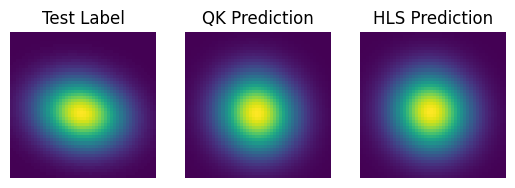

In [70]:
# Visually Compare Predictions #
index = np.random.randint(low=0, high=TEST_DATASET_SIZE)

tf_real = predictions_qk[index] * scaling_arr
hls_real = predictions_hls4ml[index] * scaling_arr

print(tf_real, hls_real)
# Recover theta from (sin2t, cos2t) via arctan2.
tf_theta  = 0.5 * np.arctan2(tf_real[4],  tf_real[5])
hls_theta  = 0.5 * np.arctan2(hls_real[4],  hls_real[5])

# Reconstruct image using parameters
tf_recon = gaussian_gen(tf_real[0], tf_real[1], tf_real[2], tf_real[3], tf_theta)
hls_recon = gaussian_gen(hls_real[0], hls_real[1], hls_real[2], hls_real[3], hls_theta)

fig, axes = plt.subplots(1, 3)
im0 = axes[0].imshow(test_img_arr[index], cmap="viridis", interpolation="none")
axes[0].set_title("Test Label")
axes[0].axis("off")

im1 = axes[1].imshow(tf_recon, cmap="viridis", interpolation="none")
axes[1].set_title("QK Prediction")
axes[1].axis("off")

im2 = axes[2].imshow(hls_recon, cmap="viridis", interpolation="none")
axes[2].set_title("HLS Prediction")
axes[2].axis("off")

plt.show()